In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
os.chdir("/content/drive/My Drive/ECE-143-main/Part2")# change path
os.getcwd()# current path

'/content/drive/My Drive/ECE-143-main/Part2'

In [5]:
import Part_2_code

In [6]:
from importlib import reload
reload(Part_2_code)

<module 'Part_2_code' from '/content/drive/MyDrive/ECE-143-main/Part2/Part_2_code.py'>

In [7]:
from pathlib import Path
from typing import Dict, Any, Tuple

import joblib
import pandas as pd
from scipy.stats import randint, uniform

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBRegressor

In [8]:
# Configuration
data_path = Path("../student_performance.csv").expanduser() # CHANGE this directory to your dataset!!!
model_save_dir = Path("./saved_models").expanduser() # CHANGE this to your desired output directory!!!
random_state = 42
test_size = 0.2
n_iter_search = 100

actionable_cols = [
    "daily_study_hours", "attendance_percentage", "motivation_score",
    "sleep_hours", "screen_time_hours", "physical_activity_minutes",
    "homework_completion_rate", "exam_anxiety_score", "study_environment"
]

In [31]:
# Load Data
X_train, X_test, y_train_reg, y_test_reg, y_train_clf, y_test_clf = Part_2_code.load_and_split_data(data_path)

# Assign explicit target variables for evaluation
y_test_score = y_test_reg
y_test_binary = y_test_clf

# Build Preprocessor
preprocessor = Part_2_code.build_preprocessor(X_train)

# Model Configuration
model_configs = Part_2_code.get_model_config()
model_performance = []
fitted_pipelines = {}

# Ensure the save directory exists before training starts
model_save_dir.mkdir(parents=True, exist_ok=True)

print("Starting multi-model hyperparameter tuning...")

# Training and Tuning Loop
for name, config in model_configs.items():
    print(f"\n--- Tuning {name} ---")

    task = config["task"]
    y_train = y_train_clf if task == "classification" else y_train_reg

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", config["estimator"])
    ])

    random_search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=config["params"],
        n_iter=n_iter_search,
        cv=5,
        scoring=config["scoring"],
        random_state=random_state,
        n_jobs=-1,
        verbose=0
    )

    # Train
    random_search.fit(X_train, y_train)
    best_model = random_search.best_estimator_

    # Save to dictionary for mapping later
    fitted_pipelines[name] = best_model

    # Store Results
    model_performance.append({
        "Model": name,
        "Task": task.capitalize(),
        "Best Params": random_search.best_params_
    })

    # Save model
    save_path = model_save_dir / f"{name}_model.pkl"
    joblib.dump(best_model, save_path)

# Display best hyperparameters
results_df = pd.DataFrame(model_performance)
print("\n-- BEST HYPERPARAMETERS --")
for _, row in results_df.iterrows():
    print(f"\n{row['Model']} ({row['Task']}):")
    for param, value in row['Best Params'].items():
        clean_param = param.replace("model__", "")
        print(f"  {clean_param}: {value}")

# Variable for evaluation and shap interpretation
knn_pipeline = fitted_pipelines["KNN"]
rf_pipeline = fitted_pipelines["RandomForest"]
xgb_pipeline = fitted_pipelines["XGBoost"]
gb_pipeline = fitted_pipelines["GradientBoosting"]

# Extract transformed data and feature names for SHAP
fitted_preprocessor = xgb_pipeline.named_steps["preprocessor"]
X_test_transformed = fitted_preprocessor.transform(X_test)
feature_names = fitted_preprocessor.get_feature_names_out()

# Extract the base estimators for ALL models
knn_model = knn_pipeline.named_steps["model"]
rf_model = rf_pipeline.named_steps["model"]
xgb_model = xgb_pipeline.named_steps["model"]
gb_model = gb_pipeline.named_steps["model"]

# Overwrite X_test with the numeric array.
X_test = X_test_transformed

print("\nReady for evaluation and SHAP analysis!")

Loaded data successfully. Using features: ['daily_study_hours', 'attendance_percentage', 'motivation_score', 'sleep_hours', 'screen_time_hours', 'physical_activity_minutes', 'homework_completion_rate', 'exam_anxiety_score', 'study_environment']
Categorical columns: ['study_environment']
Numerical columns: ['daily_study_hours', 'attendance_percentage', 'motivation_score', 'sleep_hours', 'screen_time_hours', 'physical_activity_minutes', 'homework_completion_rate', 'exam_anxiety_score']
Starting multi-model hyperparameter tuning...

--- Tuning KNN ---

--- Tuning RandomForest ---

--- Tuning XGBoost ---

--- Tuning GradientBoosting ---

-- BEST HYPERPARAMETERS --

KNN (Classification):
  n_neighbors: 11
  p: 2
  weights: uniform

RandomForest (Regression):
  max_depth: 35
  min_samples_split: 17
  n_estimators: 64

XGBoost (Regression):
  colsample_bytree: 0.9413181715946699
  learning_rate: 0.04774142166827588
  max_depth: 3
  n_estimators: 148
  subsample: 0.8501789149863856

GradientBo

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.metrics import accuracy_score, f1_score, mean_absolute_error, r2_score, confusion_matrix, roc_auc_score, roc_curve

# Set plot style
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Liberation Sans', 'Bitstream Vera Sans', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False

In [25]:
def evaluate_and_plot(knn_model, rf_model, xgb_model, gb_model, X_test, y_test_binary, y_test_score, threshold=50):
    """
    Evaluation and plotting for four models:
    - KNN: Focused on classification metrics.
    - RF, XGB, GB: Evaluated for both classification and regression (MAE) metrics.
    """
    # --- 1. Predictions ---
    # KNN typically provides class predictions directly
    knn_pred = knn_model.predict(X_test)

    # Tree models provide continuous scores (regression output or probabilities)
    rf_pred_score = rf_model.predict(X_test)
    xgb_pred_score = xgb_model.predict(X_test)
    gb_pred_score = gb_model.predict(X_test)

    # Binarize scores based on the threshold for Accuracy and F1 calculation
    rf_pred_bin = (rf_pred_score >= threshold).astype(int)
    xgb_pred_bin = (xgb_pred_score >= threshold).astype(int)
    gb_pred_bin = (gb_pred_score >= threshold).astype(int)

    # Normalize scores to [0, 1] range for AUC-ROC calculation
    # Clamping is used to ensure values stay within the valid probability range
    rf_probs = np.clip(rf_pred_score / 100, 0, 1)
    xgb_probs = np.clip(xgb_pred_score / 100, 0, 1)
    gb_probs = np.clip(gb_pred_score / 100, 0, 1)

    # --- 2. Metrics Calculation ---
    results = pd.DataFrame({
        'Model': ['KNN', 'RandomForest', 'XGBoost', 'GradientBoosting'],
        'Accuracy': [
            accuracy_score(y_test_binary, knn_pred),
            accuracy_score(y_test_binary, rf_pred_bin),
            accuracy_score(y_test_binary, xgb_pred_bin),
            accuracy_score(y_test_binary, gb_pred_bin)
        ],
        'F1-Score': [
            f1_score(y_test_binary, knn_pred),
            f1_score(y_test_binary, rf_pred_bin),
            f1_score(y_test_binary, xgb_pred_bin),
            f1_score(y_test_binary, gb_pred_bin)
        ],
        'AUC-ROC': [
            0.5, # KNN usually does not provide probabilities, so baseline is 0.5
            roc_auc_score(y_test_binary, rf_probs),
            roc_auc_score(y_test_binary, xgb_probs),
            roc_auc_score(y_test_binary, gb_probs)
        ]
    })

    # --- 3. Plotting ---
    fig, axes = plt.subplots(1, 3, figsize=(22, 6))

    # Subplot 1: Classification Comparison (Accuracy & F1)
    # Melting the dataframe to a long format for Seaborn barplot
    df_melted = results.melt(id_vars='Model', value_vars=['Accuracy', 'F1-Score'])
    sns.barplot(data=df_melted, x='variable', y='value', hue='Model', ax=axes[0], palette="muted")
    axes[0].set_title("Classification Performance", fontsize=14)
    axes[0].set_ylim(0, 1.1)
    axes[0].legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
    axes[0].grid(axis='y', linestyle='--', alpha=0.7)

    # Subplot 2: Regression Error Comparison (MAE)
    # KNN is excluded here as it's being treated as a pure classifier
    mae_rf = mean_absolute_error(y_test_score, rf_pred_score)
    mae_xgb = mean_absolute_error(y_test_score, xgb_pred_score)
    mae_gb = mean_absolute_error(y_test_score, gb_pred_score)

    mae_df = pd.DataFrame({
        'Model': ['RandomForest', 'XGBoost', 'GradientBoosting'],
        'MAE': [mae_rf, mae_xgb, mae_gb]
    })
    sns.barplot(
    data=mae_df,
    x='Model',
    y='MAE',
    hue='Model',  # Added hue to match x
    ax=axes[1],
    palette="flare",
    legend=False  # Added to hide redundant legend
)
    axes[1].set_title("Regression Error (MAE)", fontsize=14)
    # Adding data labels on top of bars
    for i, v in enumerate(mae_df['MAE']):
        axes[1].text(i, v + 0.1, f'{v:.2f}', ha='center', fontweight='bold')

    # Subplot 3: ROC Curve Comparison for Tree-based Models
    models_to_plot = [
        ('RF', rf_probs),
        ('XGB', xgb_probs),
        ('GB', gb_probs)
    ]

    for name, probs in models_to_plot:
        fpr, tpr, _ = roc_curve(y_test_binary, probs)
        auc_val = roc_auc_score(y_test_binary, probs)
        axes[2].plot(fpr, tpr, label=f'{name} (AUC = {auc_val:.2f})')

    # Plotting the random chance diagonal line
    axes[2].plot([0, 1], [0, 1], 'k--', alpha=0.5)
    axes[2].set_title("ROC Curve Comparison", fontsize=14)
    axes[2].set_xlabel("False Positive Rate")
    axes[2].set_ylabel("True Positive Rate")
    axes[2].legend(loc='lower right')
    axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    return results

In [27]:
def generate_student_report(model, X_sample, feature_names):
    """
    Generate a detailed SHAP report for a single student.
    """
    # Initialize SHAP explainer for Tree models
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_sample)

    # 1. Visualize using Waterfall Plot
    # This shows how we got from the average score to this student's predicted score
    print("Individual Diagnostic Waterfall Plot:")
    shap.plots.waterfall(shap.Explanation(values=shap_values[0],
                                         base_values=explainer.expected_value,
                                         data=X_sample[0],
                                         feature_names=feature_names))

    # 2. Automated Text Advice
    # Get the top 2 negative impact features
    idx_sorted = np.argsort(shap_values[0]) # From most negative to most positive
    top_negative_features = idx_sorted[:2]

    print("\n--- Personalized Study Advice ---")
    for idx in top_negative_features:
        feature_name = feature_names[idx]
        impact = shap_values[0][idx]
        if impact < 0:
            print(f"Warning: Your [{feature_name}] is pulling your score down by {abs(impact):.2f} points.")
            print(f"Advice: Improve your {feature_name.replace('_', ' ')} to increase your final grade.")

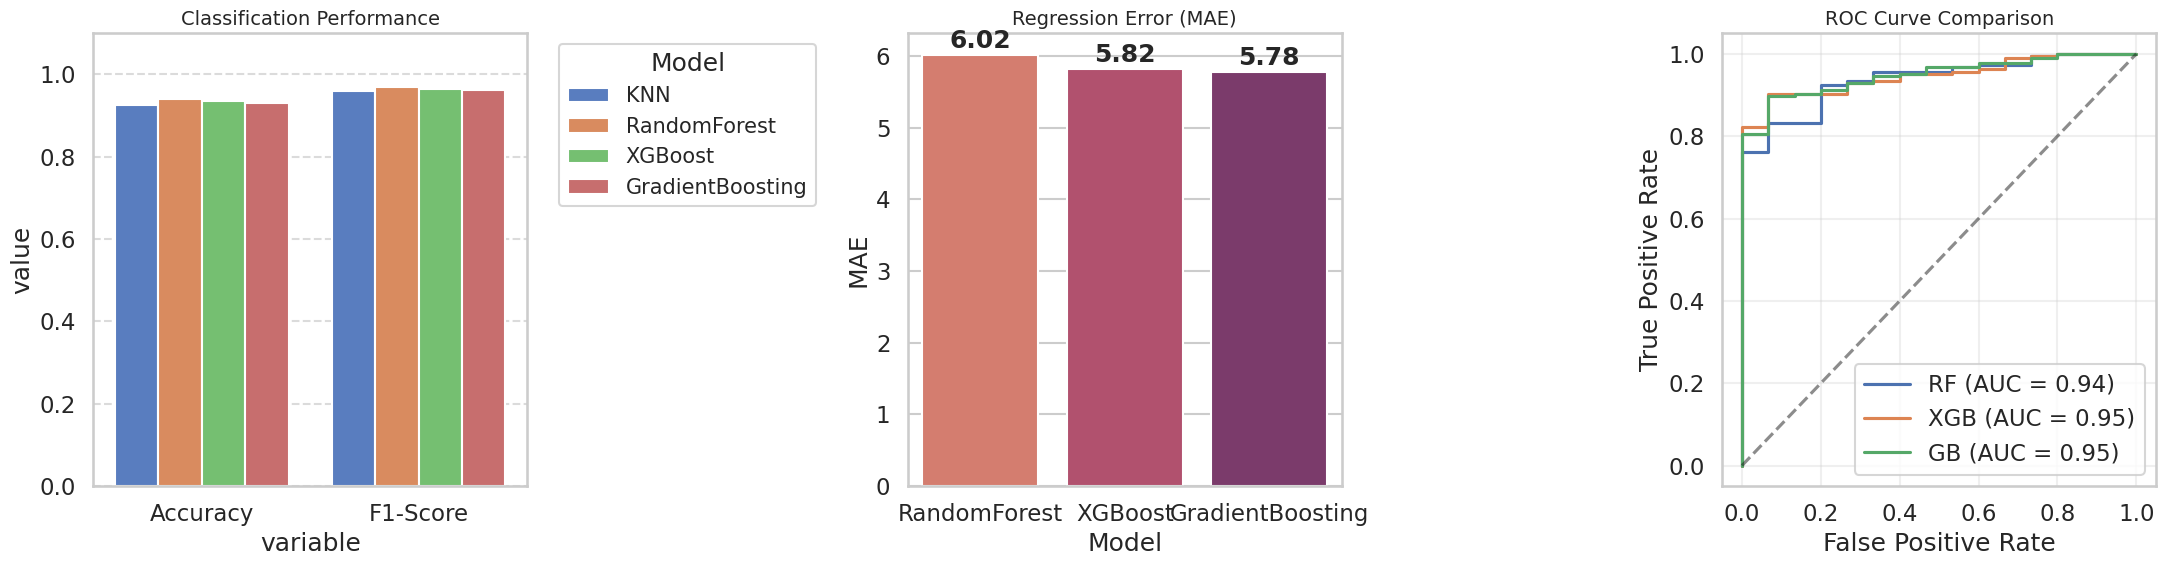

,Model,Accuracy,F1-Score,AUC-ROC
0,KNN,0.925,0.961039,0.500000
1,RandomForest,0.940,0.968421,0.937658
2,XGBoost,0.935,0.965517,0.946667
3,GradientBoosting,0.930,0.962567,0.948468


In [26]:
# 1. Run global comparison
evaluate_and_plot(knn_model, rf_model, xgb_model,gb_model, X_test, y_test_clf, y_test_reg, threshold=50)

Individual Diagnostic Waterfall Plot:


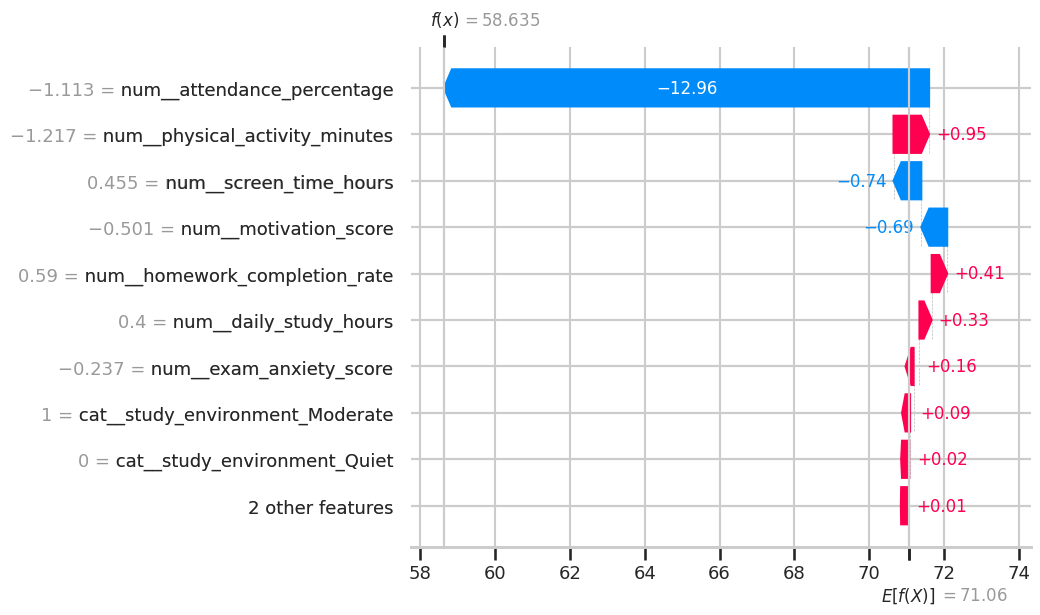


--- Personalized Study Advice ---
Advice: Improve your num  attendance percentage to increase your final grade.
Advice: Improve your num  screen time hours to increase your final grade.


In [30]:
# 2. Pick a student to diagnose
student_idx = 0
generate_student_report(xgb_model, X_test_transformed[student_idx:student_idx+1], feature_names)